<a href="https://colab.research.google.com/github/alokchoudharyguliya/Models-from-scratch/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shapes: X (1980, 20) Y (1980,)
Train: (1782, 20) (1782,) Test: (198, 20) (198,)
Parameter shapes: Wxh (16, 1) Whh (16, 16) bh (16,) Why (1, 16) by (1,)

--- Shapes during a single forward pass ---
input sequence shape: (20,)
each input x_t shape (input_dim): (1,)
hidden state h_t shape: (16,)
last hidden state h_last shape: (16,)
prediction y_pred shape: ()
Target shape: ()
-------------------------------------------

Epoch 1/10  train loss: 0.258362
Epoch 2/10  train loss: 0.255119
Epoch 3/10  train loss: 0.237758
Epoch 4/10  train loss: 0.157687
Epoch 5/10  train loss: 0.029941
Epoch 6/10  train loss: 0.009497
Epoch 7/10  train loss: 0.009370
Epoch 8/10  train loss: 0.009371
Epoch 9/10  train loss: 0.009358
Epoch 10/10  train loss: 0.009362

Test MSE loss: 0.011314986005143165


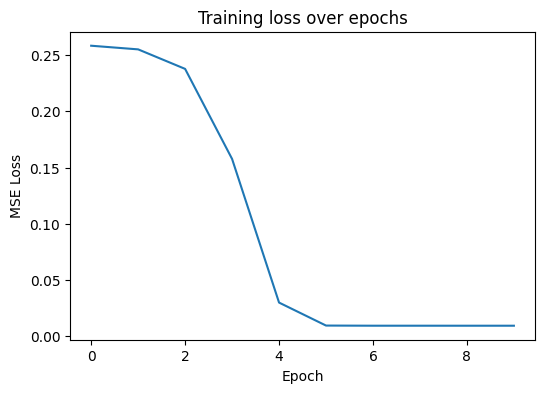

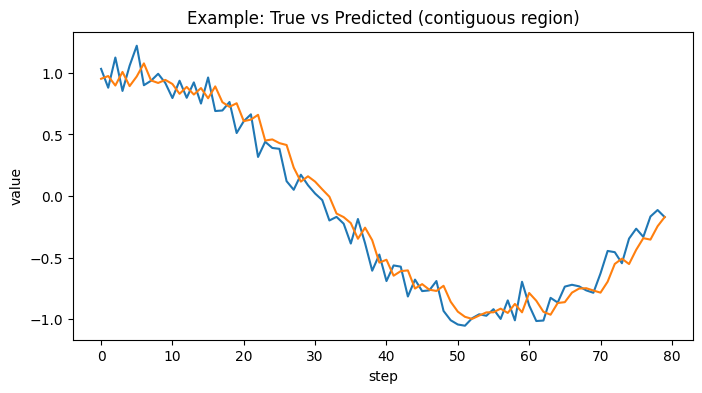


Final parameter shapes & example gradient shapes:
Wxh (16, 1) dWxh (16, 1)
Whh (16, 16) dWhh (16, 16)
Why (1, 16) dWhy (1, 16)
bh (16,) dbh (16,)
by (1,) dby (1,)
Pred 0: 0.5209  True: 0.4056
Pred 1: 0.7629  True: 1.0064
Pred 2: -0.5255  True: -0.6645
Pred 3: 0.8914  True: 1.0347
Pred 4: 0.5728  True: 0.2979
Pred 5: -0.0355  True: 0.0239


In [1]:
# Vanilla RNN tutorial + implementation on a synthetic sine-wave dataset.
# This cell trains a small vanilla RNN (from scratch using NumPy) to predict the next value
# in a sine wave sequence. It prints and demonstrates the shapes of all important variables
# and parameters, and plots training loss and example predictions.
#
# Notes on plotting: using matplotlib (single plot per figure), not specifying colors.
# The code is fully self-contained and runs here.
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------
# 1) Create a random (synthetic) dataset: sine wave time series
# -----------------------
T = 2000  # total timesteps
time = np.linspace(0, 40 * np.pi, T)
data = np.sin(time) + 0.1 * np.random.randn(T)  # sine wave + small noise

# Build sequences: for each i, input is data[i : i+seq_len], target is data[i+seq_len]
seq_len = 20
X = []
Y = []
for i in range(T - seq_len):
    X.append(data[i : i + seq_len])
    Y.append(data[i + seq_len])
X = np.array(X)  # shape: (num_samples, seq_len)
Y = np.array(Y)  # shape: (num_samples,)
print("Dataset shapes: X", X.shape, "Y", Y.shape)

# Shuffle and split into train/test
num_samples = X.shape[0]
perm = np.random.permutation(num_samples)
train_frac = 0.9
train_n = int(train_frac * num_samples)
train_idx = perm[:train_n]
test_idx = perm[train_n:]
X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]
print("Train:", X_train.shape, Y_train.shape, "Test:", X_test.shape, Y_test.shape)

# -----------------------
# 2) Define a small vanilla RNN (single hidden layer) from scratch
#    We'll do sequence-to-one prediction (predict next value after seq_len inputs).
# -----------------------
class VanillaRNN:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=1e-3):
        # Parameters (weights & biases)
        # W_xh: (hidden_dim, input_dim)
        # W_hh: (hidden_dim, hidden_dim)
        # b_h : (hidden_dim,)
        # W_hy: (output_dim, hidden_dim)
        # b_y : (output_dim,)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = learning_rate

        # Initialize weights with small values
        self.Wxh = np.random.randn(hidden_dim, input_dim) * 0.01
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * 0.01
        self.bh = np.zeros((hidden_dim,))
        self.Why = np.random.randn(output_dim, hidden_dim) * 0.01
        self.by = np.zeros((output_dim,))

        # For debugging: show shapes
        print("Parameter shapes: Wxh", self.Wxh.shape, "Whh", self.Whh.shape,
              "bh", self.bh.shape, "Why", self.Why.shape, "by", self.by.shape)

    def forward(self, inputs):
        # inputs: shape (seq_len,) or (seq_len, input_dim) - here input_dim=1, so we shape accordingly
        h_prev = np.zeros((self.hidden_dim,))
        hs = []  # store hidden states for each timestep
        xs = []  # store inputs processed
        for t in range(len(inputs)):
            x_t = np.array([inputs[t]]) if self.input_dim == 1 else inputs[t]
            # x_t shape: (input_dim,)
            # compute hidden state: h_t = tanh(Wxh x_t + Whh h_prev + bh)
            # Wxh @ x_t -> (hidden_dim,)
            preact = self.Wxh.dot(x_t) + self.Whh.dot(h_prev) + self.bh
            h_t = np.tanh(preact)
            hs.append(h_t)
            xs.append(x_t)
            h_prev = h_t

        # Sequence-to-one: use last hidden state to produce output
        y_pred = self.Why.dot(h_prev) + self.by  # shape: (output_dim,)
        # Convert to scalar if output_dim==1
        if self.output_dim == 1:
            y_pred = y_pred.squeeze()
        # Return prediction and caches for backward
        cache = {"xs": xs, "hs": hs, "h_last": h_prev}
        return y_pred, cache

    def compute_loss(self, y_pred, y_true):
        # Mean squared error (scalar)
        return 0.5 * (y_pred - y_true) ** 2

    def backward(self, y_pred, y_true, cache):
        # Compute gradients via BPTT (manual)
        # We'll compute gradients of MSE loss w.r.t parameters
        xs = cache["xs"]  # list of length seq_len, each shape (input_dim,)
        hs = cache["hs"]  # list of hidden states (hidden_dim,)
        h_last = cache["h_last"]
        seq_len = len(xs)

        # Initialize gradients with same shapes as params
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)
        dWhy = np.zeros_like(self.Why)
        dby = np.zeros_like(self.by)

        # dLoss/dy_pred for MSE
        dL_dy = (y_pred - y_true)  # scalar if output_dim==1

        # grad for output layer
        # y_pred = Why @ h_last + by
        # shapes: Why (1, hidden_dim), h_last (hidden_dim,)
        dWhy += np.atleast_2d(dL_dy).T.dot(h_last.reshape(1, -1)) if self.output_dim != 1 else (np.array(dL_dy).reshape(1,1).dot(h_last.reshape(1,-1))).reshape(self.Why.shape)
        # simpler: compute as outer product consistent with shapes
        if self.output_dim == 1:
            dWhy = (dL_dy * h_last).reshape(1, -1)
        dby += np.atleast_1d(dL_dy)

        # Backprop into last hidden state
        # dL/dh_last = Why^T * dL/dy
        dh_next = self.Why.T.dot(np.atleast_1d(dL_dy)).reshape(-1)  # shape: (hidden_dim,)
        # Now backprop through time
        for t in reversed(range(seq_len)):
            h_t = hs[t]  # current hidden state
            # derivative of tanh preactivation: dtanh = (1 - h_t^2)
            dtanh = (1 - h_t ** 2) * dh_next  # shape: (hidden_dim,)
            # dbh
            dbh += dtanh
            # dWxh += dtanh[:, None] @ x_t[None, :]
            x_t = xs[t]  # shape (input_dim,)
            dWxh += np.outer(dtanh, x_t)  # (hidden_dim, input_dim)
            # dWhh += dtanh[:, None] @ h_prev[None, :]
            h_prev = hs[t - 1] if t > 0 else np.zeros_like(h_t)
            dWhh += np.outer(dtanh, h_prev)
            # propagate dh to previous step: dh_next = Whh^T @ dtanh
            dh_next = self.Whh.T.dot(dtanh)

        # Clip gradients to avoid explosion
        for g in [dWxh, dWhh, dbh, dWhy, dby]:
            np.clip(g, -5, 5, out=g)

        grads = {"dWxh": dWxh, "dWhh": dWhh, "dbh": dbh, "dWhy": dWhy, "dby": dby}
        return grads

    def step(self, grads):
        # SGD update
        self.Wxh -= self.lr * grads["dWxh"]
        self.Whh -= self.lr * grads["dWhh"]
        self.bh  -= self.lr * grads["dbh"]
        self.Why -= self.lr * grads["dWhy"]
        self.by  -= self.lr * grads["dby"]

# -----------------------
# 3) Train the RNN
# -----------------------
input_dim = 1
hidden_dim = 16
output_dim = 1
rnn = VanillaRNN(input_dim, hidden_dim, output_dim, learning_rate=1e-3)

# Training hyperparams
epochs = 10
batch_size = 32
num_train = X_train.shape[0]
losses = []

# Helper: get batch and reshape for input_dim=1
def get_batch(Xarr, Yarr, i, bsize):
    xb = Xarr[i:i+bsize]
    yb = Yarr[i:i+bsize]
    return xb, yb

for epoch in range(epochs):
    perm = np.random.permutation(num_train)
    epoch_loss = 0.0
    for i in range(0, num_train, batch_size):
        batch_idx = perm[i:i+batch_size]
        xb = X_train[batch_idx]  # shape: (b, seq_len)
        yb = Y_train[batch_idx]  # shape: (b,)
        batch_losses = []
        # We'll do simple online updates for each sequence in batch (not vectorized) to keep code clear
        for j in range(len(xb)):
            seq = xb[j]  # shape (seq_len,)
            target = yb[j]  # scalar
            y_pred, cache = rnn.forward(seq)
            loss = rnn.compute_loss(y_pred, target)
            grads = rnn.backward(y_pred, target, cache)
            rnn.step(grads)
            batch_losses.append(loss)
            # For the first sample of first batch of first epoch print shapes to illustrate
            if epoch == 0 and i == 0 and j == 0:
                print("\n--- Shapes during a single forward pass ---")
                print("input sequence shape:", seq.shape)
                print("each input x_t shape (input_dim):", np.array([seq[0]]).shape)
                print("hidden state h_t shape:", cache["hs"][0].shape)
                print("last hidden state h_last shape:", cache["h_last"].shape)
                print("prediction y_pred shape:", np.array(y_pred).shape)
                print("Target shape:", np.array(target).shape)
                print("-------------------------------------------\n")
        epoch_loss += np.sum(batch_losses)
    epoch_loss /= num_train
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}  train loss: {epoch_loss:.6f}")

# -----------------------
# 4) Evaluate on test set and show some predictions
# -----------------------
test_losses = []
preds = []
for i in range(len(X_test)):
    seq = X_test[i]
    target = Y_test[i]
    y_pred, _ = rnn.forward(seq)
    test_losses.append(0.5 * (y_pred - target) ** 2)
    preds.append(y_pred)
test_loss = np.mean(test_losses)
print("\nTest MSE loss:", test_loss)

# Plot training loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)  # single plot
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# Show example prediction vs true on a contiguous region from the original series
# Pick a start index in original data (not shuffled) to visualize
viz_start = 100
viz_seqs = []
viz_targets = []
viz_preds = []
for i in range(viz_start, viz_start + 80):
    seq = data[i : i + seq_len]
    target = data[i + seq_len]
    y_pred, _ = rnn.forward(seq)
    viz_seqs.append(seq[-1])  # last input
    viz_targets.append(target)
    viz_preds.append(y_pred)

plt.figure(figsize=(8,4))
plt.plot(viz_targets)  # true next values
plt.plot(viz_preds)    # predicted next values
plt.title("Example: True vs Predicted (contiguous region)")
plt.xlabel("step")
plt.ylabel("value")
plt.show()

# Print a brief summary of parameter shapes again and gradient example (on last sample)
y_pred, cache = rnn.forward(X_test[0])
grads = rnn.backward(y_pred, Y_test[0], cache)
print("\nFinal parameter shapes & example gradient shapes:")
print("Wxh", rnn.Wxh.shape, "dWxh", grads["dWxh"].shape)
print("Whh", rnn.Whh.shape, "dWhh", grads["dWhh"].shape)
print("Why", rnn.Why.shape, "dWhy", grads["dWhy"].shape)
print("bh", rnn.bh.shape, "dbh", grads["dbh"].shape)
print("by", rnn.by.shape, "dby", grads["dby"].shape)

# Show a few predicted vs actual values
for i in range(6):
    print(f"Pred {i}: {preds[i]:.4f}  True: {Y_test[i]:.4f}")
